# Anatomical Localization with `ndx-anatomical-localization`

This notebook shows how to stream and visualise the atlas-registration and
anatomical-coordinate data from [DANDI:001713](https://dandiarchive.org/dandiset/001713)
(embargoed) using the
[`ndx-anatomical-localization`](https://github.com/catalystneuro/ndx-anatomical-localization)
NWB extension.

## Extension overview

| Type | Where | Description |
|---|---|---|
| `AtlasRegistration` | `nwbfile.lab_meta_data["atlas_registration"]` | Images + affine transform + landmarks |
| `Localization` | `nwbfile.lab_meta_data["localization"]` | Per-pixel coordinates + region masks + coordinate tables |
| `AffineTransformation` | inside `AtlasRegistration` | 3×3 homogeneous matrix: source px → registered px |
| `Landmarks` | inside `AtlasRegistration` | Manually placed control-point table |
| `AnatomicalCoordinatesImage` | `localization.anatomical_coordinates_images` | Per-pixel `(x, y, z)` + region acronym arrays |
| `BrainRegionMasks` | `localization.brain_region_masks` | Sparse `(x, y, brain_region_id)` table |
| `AnatomicalCoordinatesTable` | `localization.anatomical_coordinates_tables` | 3-D coordinates for discrete objects (landmarks) |

## Contents

1. [Setup and Data Access](#setup)
2. [Atlas Registration](#atlas-registration)
   - [Summary images](#images)
   - [Affine Transformation](#affine)
   - [Landmarks table](#landmarks)
3. [Anatomical Coordinates Image](#aci)
4. [Brain Region Masks](#brm)
5. [Anatomical Coordinates Tables](#act)

---

## 1. Setup and Data Access <a id="setup"></a>

In [1]:
# IMPORTANT: import ndx_anatomical_localization BEFORE reading the NWB file.
# This registers custom types so PyNWB can deserialise them correctly.
import ndx_anatomical_localization  # noqa: F401

import h5py
import matplotlib.patches as mpatches
import matplotlib.pyplot as plt
import numpy as np
import remfile
from dandi.dandiapi import DandiAPIClient
from matplotlib.colors import ListedColormap
from pynwb import NWBHDF5IO
from skimage.transform import SimilarityTransform

plt.rcParams["figure.figsize"] = (12, 6)
plt.rcParams["font.size"] = 10

In [2]:
def load_nwb_from_dandi(dandiset_id, subject_id, session_id, desc="processed"):
    """
    Stream an NWB file from the DANDI Archive.

    For embargoed dandisets, DANDI_API_KEY must be set in the environment
    or you will be prompted to authenticate.
    """
    pattern = f"sub-{subject_id}/sub-{subject_id}_ses-{session_id}_desc-{desc}_*.nwb"

    with DandiAPIClient() as client:
        client.dandi_authenticate()  # Required for embargoed dandisets
        assets = list(
            client.get_dandiset(dandiset_id, "draft").get_assets_by_glob(
                pattern=pattern, order="path"
            )
        )

        if len(assets) != 1:
            raise ValueError(f"Expected 1 file, found {len(assets)} for pattern '{pattern}'")

        s3_url = assets[0].get_content_url(follow_redirects=1, strip_query=False)

    file = remfile.File(s3_url)
    h5_file = h5py.File(file, "r")
    io = NWBHDF5IO(file=h5_file, load_namespaces=True)
    nwbfile = io.read()
    return nwbfile, io

In [3]:
dandiset_id = "001713"        # Embargoed IBL widefield dandiset
subject_id  = "CSK-im-009"   # Example CSK subject — update as needed
session_id  = "2864dca1-38d8-464c-9777-f6fdfd5e63b5"  # Example session EID

# Atlas registration is present in both raw and processed files.
# Use processed here as it also contains SVD summary images.
nwbfile, io = load_nwb_from_dandi(dandiset_id, subject_id, session_id, desc="processed")
print("NWB file loaded successfully.")

NWB file loaded successfully.


---

## 2. Atlas Registration <a id="atlas-registration"></a>

`AtlasRegistration` lives at `nwbfile.lab_meta_data["atlas_registration"]` and groups
all outputs of the atlas-registration pipeline:

| Field | Type | Description |
|---|---|---|
| `source_image` | `GrayscaleImage` | Mean FOV in camera space |
| `registered_image` | `GrayscaleImage` | FOV after affine warp to atlas space |
| `atlas_projection` | `GrayscaleImage` | 2-D Allen CCF dorsal-cortex reference |
| `affine_transformation` | `AffineTransformation` | 3×3 homogeneous matrix |
| `landmarks` | `Landmarks` | Manually placed control-point table |

In [4]:
atlas_registration = nwbfile.lab_meta_data["atlas_registration"]
print(atlas_registration)

atlas_registration ndx_anatomical_localization.ndx_anatomical_localization.AtlasRegistration at 0x4993124928
Fields:
  affine_transformation: AffineTransformation ndx_anatomical_localization.ndx_anatomical_localization.AffineTransformation at 0x5051664720
Fields:
  affine_matrix: [[-1.19177205e-01  9.66756560e-01  6.82827028e+01]
 [-9.66756560e-01 -1.19177205e-01  5.97948629e+02]
 [ 0.00000000e+00  0.00000000e+00  1.00000000e+00]]

  atlas_projection: AtlasProjectionImage <class 'pynwb.image.GrayscaleImage'>
  landmarks: landmarks <class 'abc.Landmarks'>
  registered_image: RegisteredImage <class 'pynwb.image.GrayscaleImage'>
  source_image: MeanImage <class 'pynwb.image.GrayscaleImage'>



### Summary Images <a id="images"></a>

In [5]:
source_img     = atlas_registration.source_image.data[:]     # raw FOV (camera space)
registered_img = atlas_registration.registered_image.data[:] # affine-warped to atlas space
atlas_proj     = atlas_registration.atlas_projection.data[:] # Allen CCF dorsal-cortex reference

print(f"source_image shape     : {source_img.shape}")
print(f"registered_image shape : {registered_img.shape}")
print(f"atlas_projection shape : {atlas_proj.shape}")

source_image shape     : (540, 640)
registered_image shape : (540, 640)
atlas_projection shape : (1320, 1140)


### Affine Transformation <a id="affine"></a>

`AffineTransformation` stores a 3×3 matrix in homogeneous coordinates that maps
pixel positions from the **source** (camera) image to the **registered** (atlas-aligned)
image.  The inverse maps registered pixels back to source space.

In [6]:
affine_transform = atlas_registration.affine_transformation
M = SimilarityTransform(affine_transform.affine_matrix)

print("Affine matrix (3×3 homogeneous — source px → registered px):")
for row in affine_transform.affine_matrix:
    print(f"  [{row[0]: .5f}  {row[1]: .5f}  {row[2]: .5f}]")

Affine matrix (3×3 homogeneous — source px → registered px):
  [-0.11918   0.96676   68.28270]
  [-0.96676  -0.11918   597.94863]
  [ 0.00000   0.00000   1.00000]


### Landmarks Table <a id="landmarks"></a>

`Landmarks` is a `DynamicTable` of manually identified control points used to
estimate the affine transform. Each row is one anatomical landmark.

| Column | Description |
|---|---|
| `source_x`, `source_y` | Pixel coords in the raw (source) FOV |
| `registered_x`, `registered_y` | Pixel coords in the registered (atlas-aligned) FOV |
| `reference_x`, `reference_y` | Pixel coords in the Allen dorsal-cortex atlas projection |
| `landmark_labels` | Anatomical label string (e.g. `"OB_center"`, `"RSP_base"`) |
| `bregma_offset_x`, `bregma_offset_y` | Bregma position in atlas projection pixel coords |
| `resolution` | µm per pixel of the atlas reference projection |

In [7]:
landmarks = atlas_registration.landmarks
print(landmarks.description)
landmarks_df = landmarks[:]
landmarks_df

Anatomical landmarks for Allen CCF alignment. Origin (0, 0) corresponds to the top-left corner of the image.


,source_x,source_y,registered_x,registered_y,reference_x,reference_y,landmark_labels,color,bregma_offset_x,bregma_offset_y,resolution
id,,,,,,,,,,,
0,122.828237,374.740614,219.484536,92.164948,375.0,195.0,OB_left,#fc9d03,320,270,19.4
1,130.722445,277.078329,320.000000,92.164948,570.0,195.0,OB_center,#0367fc,320,270,19.4
2,103.608284,182.378204,420.515464,92.164948,765.0,195.0,OB_right,#fc9d03,320,270,19.4
3,451.217499,235.361147,320.000000,434.948454,570.0,860.0,RSP_base,#fc4103,320,270,19.4


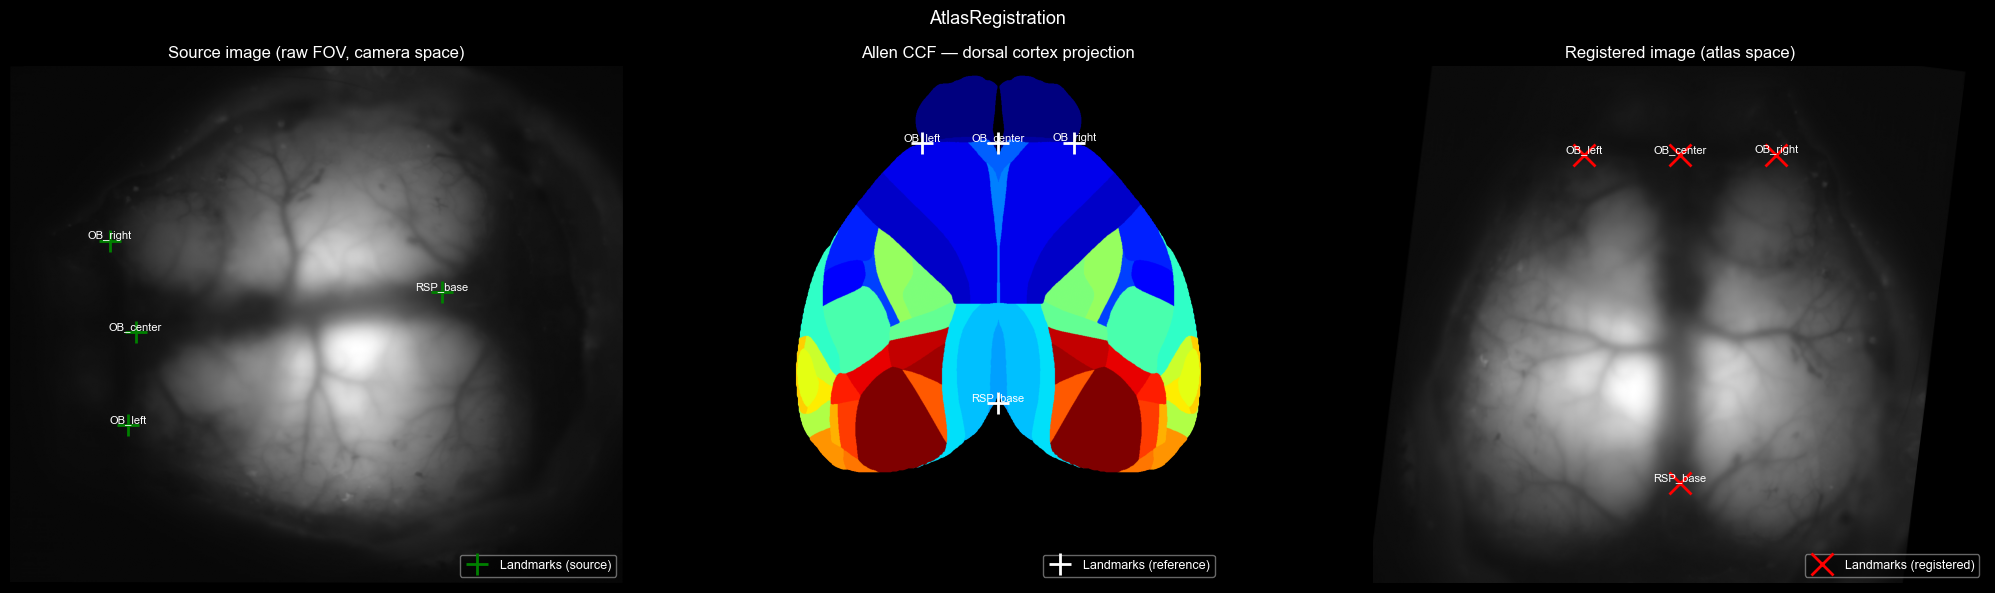

In [8]:
fig, axes = plt.subplots(1, 3, figsize=(21, 6), dpi=100)

# --- Source image ---
axes[0].imshow(source_img, cmap="gray")
axes[0].plot(
    landmarks_df["source_x"], landmarks_df["source_y"],
    "g+", ms=16, mew=2, label="Landmarks (source)",
)
for _, row in landmarks_df.iterrows():
    axes[0].text(
        row["source_x"], row["source_y"], row["landmark_labels"],
        color="w", fontsize=8, va="bottom", ha="center",
    )
axes[0].set_title("Source image (raw FOV, camera space)")
axes[0].axis("off")
axes[0].legend(loc="lower right", fontsize=9, frameon=True, facecolor="black", framealpha=0.5)

# --- Atlas projection ---
proj_masked = np.ma.masked_equal(atlas_proj, 0)
cmap_jet = plt.get_cmap("jet").copy()
cmap_jet.set_bad(alpha=0)
axes[1].imshow(proj_masked, cmap=cmap_jet)
axes[1].plot(
    landmarks_df["reference_x"], landmarks_df["reference_y"],
    "w+", ms=16, mew=2, label="Landmarks (reference)",
)
for _, row in landmarks_df.iterrows():
    axes[1].text(
        row["reference_x"], row["reference_y"], row["landmark_labels"],
        color="w", fontsize=8, va="bottom", ha="center",
    )
axes[1].set_title("Allen CCF — dorsal cortex projection")
axes[1].axis("off")
axes[1].legend(loc="lower right", fontsize=9, frameon=True, facecolor="black", framealpha=0.5)

# --- Registered image ---
axes[2].imshow(registered_img, cmap="gray")
axes[2].plot(
    landmarks_df["registered_x"], landmarks_df["registered_y"],
    "rx", ms=16, mew=2, label="Landmarks (registered)",
)
for _, row in landmarks_df.iterrows():
    axes[2].text(
        row["registered_x"], row["registered_y"], row["landmark_labels"],
        color="w", fontsize=8, va="bottom", ha="center",
    )
axes[2].set_title("Registered image (atlas space)")
axes[2].axis("off")
axes[2].legend(loc="lower right", fontsize=9, frameon=True, facecolor="black", framealpha=0.5)

plt.suptitle("AtlasRegistration", fontsize=13)
plt.tight_layout()
plt.show()

---

## 3. Anatomical Coordinates Image <a id="aci"></a>

`AnatomicalCoordinatesImage` assigns a physical 3-D coordinate and a brain-region
label to every pixel in an image.  It lives under
`nwbfile.lab_meta_data["localization"].anatomical_coordinates_images`.

For IBL sessions one instance is stored per file:

| Name | Linked to | Description |
|---|---|---|
| `AnatomicalCoordinatesImageIBLBregma` | `GrayscaleImage` (`RegisteredImage`) | Registered-space per-pixel IBL bregma coordinates |

Coordinate system: **IBL Bregma (RAS)**, origin = bregma, units = µm.

| Array | Shape | Description |
|---|---|---|
| `x` | `(H, W)` | Mediolateral (positive = Right) |
| `y` | `(H, W)` | Anteroposterior (positive = Anterior) |
| `z` | `(H, W)` | Dorsoventral (positive = Superior; ≈ 0 for 2-D FOV) |
| `brain_region` | `(H, W)` | Allen acronym string (`"out-of-atlas"` outside atlas) |

In [9]:
localization = nwbfile.lab_meta_data["localization"]
aci = localization.anatomical_coordinates_images["AnatomicalCoordinatesImageIBLBregma"]

space        = aci.space
x_coords     = aci.x[:]               # ML in µm
y_coords     = aci.y[:]               # AP in µm
region_names = np.asarray(aci.brain_region[:])
in_atlas     = region_names != "out-of-atlas"

print(f"Name          : {aci.name}")
print(f"Description   : {aci.description}")
print(f"Space         : {space.space_name}")
print(f"  Origin      : {space.origin}")
print(f"  Units       : {space.units}")
print(f"  Orientation : {space.orientation}  (x={space.orientation[0]}, y={space.orientation[1]}, z={space.orientation[2]})")
print(f"Image shape   : {aci.image.data[:].shape}")
print(f"ML (x) range  : [{x_coords[in_atlas].min():.0f}, {x_coords[in_atlas].max():.0f}] µm")
print(f"AP (y) range  : [{y_coords[in_atlas].min():.0f}, {y_coords[in_atlas].max():.0f}] µm")
print(f"Brain regions : {len(np.unique(region_names[in_atlas]))} unique Allen acronyms in atlas")

Name          : AnatomicalCoordinatesImageIBLBregma
Description   : Transformed mean image estimated coordinates in IBL bregma-centered coordinate system.
Space         : IBLBregma
  Origin      : bregma
  Units       : um
  Orientation : RAS  (x=R, y=A, z=S)
Image shape   : (540, 640)
ML (x) range  : [-5160, 5160] µm
AP (y) range  : [-8416, 1710] µm
Brain regions : 33 unique Allen acronyms in atlas


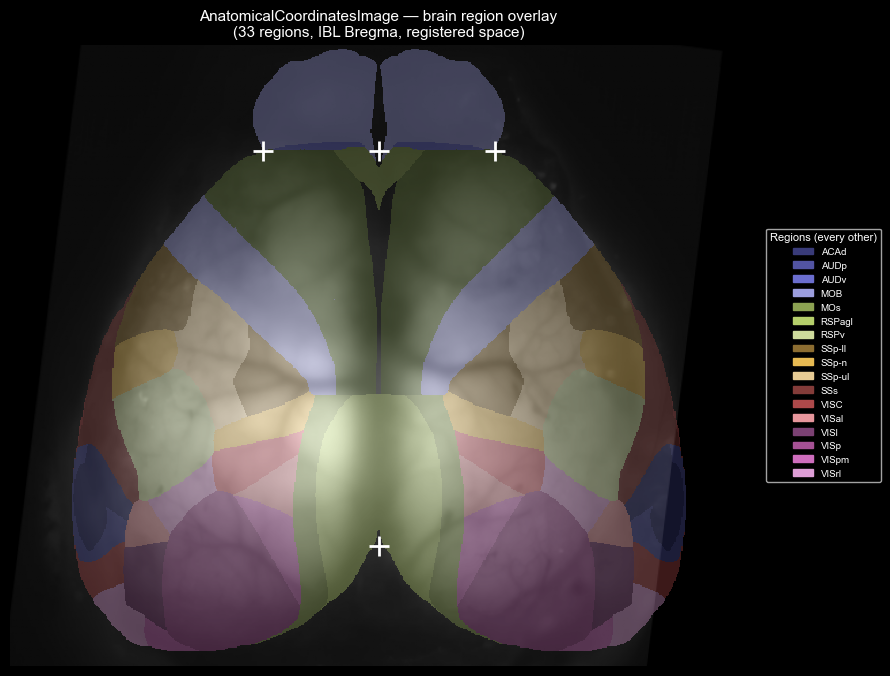

In [10]:
# Brain region overlay on the registered image
background   = "out-of-atlas"
names        = np.unique(region_names)
names        = names[names != background]
n            = len(names)
name_to_idx  = {name: i + 1 for i, name in enumerate(names)}

idx_img = np.zeros(region_names.shape, dtype=np.int16)
for name, i in name_to_idx.items():
    idx_img[region_names == name] = i
idx_masked = np.ma.masked_where(idx_img == 0, idx_img)

base_cmap   = plt.get_cmap("tab20b", max(n, 1))
colors      = np.vstack([[0, 0, 0, 0], base_cmap(np.arange(n))])
region_cmap = ListedColormap(colors)
region_cmap.set_bad(alpha=0)

fig, ax = plt.subplots(figsize=(9, 8), dpi=100)
ax.imshow(registered_img, cmap="gray")
ax.imshow(idx_masked, cmap=region_cmap, alpha=0.35, interpolation="nearest")
ax.plot(
    landmarks_df["registered_x"], landmarks_df["registered_y"],
    "w+", ms=14, mew=2, label="Landmarks",
)
ax.set_title(
    f"AnatomicalCoordinatesImage — brain region overlay\n({n} regions, IBL Bregma, registered space)",
    fontsize=11,
)
ax.axis("off")

handles = [
    mpatches.Patch(color=region_cmap(name_to_idx[name]), label=name)
    for name in names[::2]  # every other region to keep legend readable
]
ax.legend(
    handles=handles,
    loc="center left", bbox_to_anchor=(1.02, 0.5),
    frameon=True, title="Regions (every other)",
    fontsize=7, title_fontsize=8,
)
plt.tight_layout()
plt.show()

---

## 4. Brain Region Masks <a id="brm"></a>

`BrainRegionMasks` is a **sparse** `DynamicTable` — one row per in-atlas pixel —
mapping pixel position to Allen integer structure ID.

| Column | Dtype | Description |
|---|---|---|
| `x` | `int32` | Pixel column |
| `y` | `int32` | Pixel row |
| `brain_region_id` | `int32` | Allen Brain Atlas integer ID |

Two masks are stored under `localization.brain_region_masks`:

| Name | Space |
|---|---|
| `RegisteredImageBrainRegionMasksIBLBregma` | Registered (atlas-aligned) FOV |
| `SourceImageBrainRegionMasksIBLBregma` | Source (camera) FOV — masks warped back via inverse affine |

In [12]:
print("=== Brain Region Masks ===")
for name, masks in localization.brain_region_masks.items():
    unique_ids = np.unique(masks["brain_region_id"].data[:])
    print(f"  {name}")
    print(f"    Rows (in-atlas pixels) : {len(masks)}")
    print(f"    Unique region IDs      : {len(unique_ids)}")
    print()

=== Brain Region Masks ===
  RegisteredImageBrainRegionMasksIBLBregma
    Rows (in-atlas pixels) : 204542
    Unique region IDs      : 33

  SourceImageBrainRegionMasksIBLBregma
    Rows (in-atlas pixels) : 192088
    Unique region IDs      : 33



In [13]:
reg_masks = localization.brain_region_masks["RegisteredImageBrainRegionMasksIBLBregma"]
src_masks = localization.brain_region_masks["SourceImageBrainRegionMasksIBLBregma"]

H, W = registered_img.shape
reg_id_img = reg_masks._to_image(image_height=H, image_width=W)
src_id_img = src_masks._to_image(image_height=source_img.shape[0], image_width=source_img.shape[1])

print(f"Dense array shape (registered): {reg_id_img.shape}, dtype: {reg_id_img.dtype}")
print(f"Dense array shape (source)    : {src_id_img.shape}, dtype: {src_id_img.dtype}")

Dense array shape (registered): (540, 640), dtype: int32
Dense array shape (source)    : (540, 640), dtype: int32


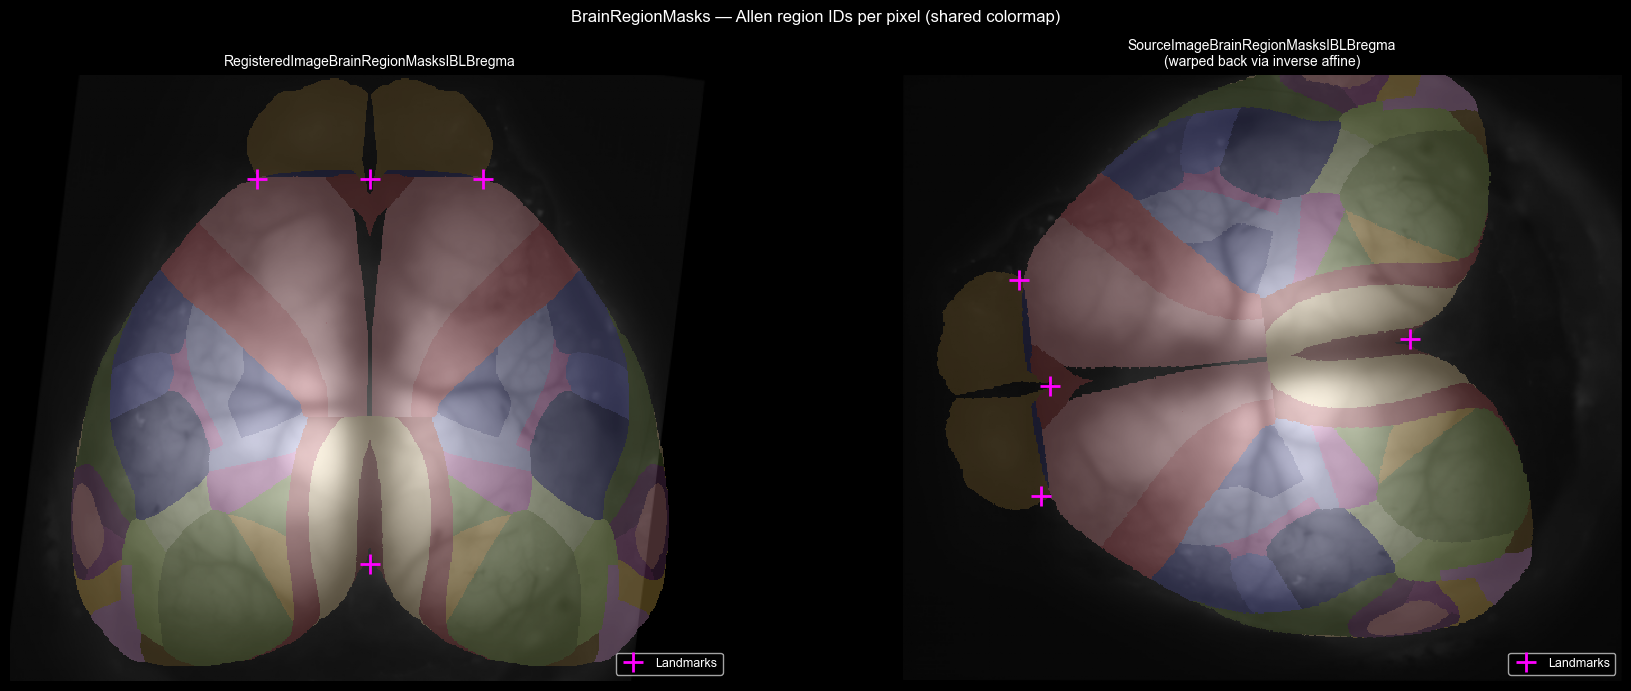

In [14]:
# Build a colormap indexed by Allen region ID (shared between both images)
unique_ids  = np.unique(reg_id_img[reg_id_img != 0])
n_ids       = len(unique_ids)
id_to_cidx  = {int(rid): i + 1 for i, rid in enumerate(unique_ids)}
id_to_cidx[0] = 0

base_cmap  = plt.get_cmap("tab20b", max(n_ids, 1))
colors_arr = np.vstack([[0, 0, 0, 0], base_cmap(np.arange(n_ids))])
mask_cmap  = ListedColormap(colors_arr)
mask_cmap.set_bad(alpha=0)


def id_img_to_display(id_img):
    cmap_img = np.vectorize(id_to_cidx.get)(id_img)
    return np.ma.masked_where(cmap_img == 0, cmap_img)


fig, axes = plt.subplots(1, 2, figsize=(18, 7), dpi=100)

# Registered space
axes[0].imshow(registered_img, cmap="gray")
axes[0].imshow(id_img_to_display(reg_id_img), cmap=mask_cmap, alpha=0.3, interpolation="nearest")
axes[0].plot(landmarks_df["registered_x"], landmarks_df["registered_y"], "+", color="magenta", ms=14, mew=2, label="Landmarks")
axes[0].set_title("RegisteredImageBrainRegionMasksIBLBregma", fontsize=10)
axes[0].axis("off")
axes[0].legend(loc="lower right", fontsize=9)

# Source space
axes[1].imshow(source_img, cmap="gray")
axes[1].imshow(id_img_to_display(src_id_img), cmap=mask_cmap, alpha=0.3, interpolation="nearest")
axes[1].plot(landmarks_df["source_x"], landmarks_df["source_y"], "+", color="magenta", ms=14, mew=2, label="Landmarks")
axes[1].set_title("SourceImageBrainRegionMasksIBLBregma\n(warped back via inverse affine)", fontsize=10)
axes[1].axis("off")
axes[1].legend(loc="lower right", fontsize=9)

plt.suptitle("BrainRegionMasks — Allen region IDs per pixel (shared colormap)", fontsize=12)
plt.tight_layout()
plt.show()

---

## 5. Anatomical Coordinates Tables <a id="act"></a>

`AnatomicalCoordinatesTable` stores 3-D anatomical coordinates for discrete
objects (the registration landmarks here).  Each row gives `(x, y, z)` in a
named `Space` and a back-reference (`localized_entity`) to the `Landmarks` table.

Two tables are stored per session under `localization.anatomical_coordinates_tables`:

| Name | Space | Orientation | Description |
|---|---|---|---|
| `AnatomicalCoordinatesIBLBregma` | IBL Bregma | RAS | x=ML, y=AP, z=DV; bregma=origin; µm |
| `AnatomicalCoordinatesCCFv3` | Allen CCFv3 | PIR | x=AP, y=DV, z=ML; ASL corner=origin; µm |

In [15]:
ibl_table = localization.anatomical_coordinates_tables["AnatomicalCoordinatesIBLBregma"]

print(f"Space      : {ibl_table.space.space_name}")
print(f"  Origin   : {ibl_table.space.origin}")
print(f"  Orient.  : {ibl_table.space.orientation}")
print(f"  Units    : {ibl_table.space.units}")
print(f"Method     : {ibl_table.method}")
print()
ibl_table[:]

Space      : IBLBregma
  Origin   : bregma
  Orient.  : RAS
  Units    : um
Method     : IBL manual annotation



,x,y,z,localized_entity,brain_region
id,,,,,
0,-1950.0,-3450.0,0.0,0,OB_left
1,0.0,-3450.0,0.0,1,OB_center
2,1950.0,-3450.0,0.0,2,OB_right
3,0.0,3200.0,0.0,3,RSP_base


In [16]:
ccf_table = localization.anatomical_coordinates_tables["AnatomicalCoordinatesCCFv3"]

print(f"Space      : {ccf_table.space.space_name}")
print(f"  Origin   : {ccf_table.space.origin}")
print(f"  Orient.  : {ccf_table.space.orientation}")
print(f"  Units    : {ccf_table.space.units}")
print(f"Method     : {ccf_table.method}")
print()
ccf_table[:]

Space      : AllenCCFv3
  Origin   : Anterior-Superior-Left (ASL) corner of the 3D image volume
  Orient.  : PIR
  Units    : um
Method     : IBL manual annotation



,x,y,z,localized_entity,brain_region
id,,,,,
0,8850.0,332.0,3789.0,0,OB_left
1,8850.0,332.0,5739.0,1,OB_center
2,8850.0,332.0,7689.0,2,OB_right
3,2200.0,332.0,5739.0,3,RSP_base
